# Supplementary Material 2 (S2): Data-Loss Comparison

This notebook reproduces the supplementary comparison between the MSE and GLS data-loss formulations for the 1D Case I setting.

The notebook contains:

1. The fixed Case I data and shared training assumptions used by both data-loss formulations.
2. The BINN model catalogue, filtered and loaded for the MSE and GLS data-loss formulations.
3. The S2 comparison panels for validation loss, diffusion MSE, loss components, diagnostics, and diffusion evolution across epochs.

*It produces plots for Fig. S7 in the paper.*


In [1]:
import os
import sys
from pathlib import Path

import numpy as np

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    build_model_path,
    filter_model_catalog,
    load_requested_models,
    summarize_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root
DATA_ROOT = paths.data_root
BINN_ROOT = paths.binn_root

register_notebook_pickle_globals()

from paper_helpers import (
    scale_function_by_percent_error,
    plot_data_loss_diagnostics,
    plot_diffusion_across_epochs,
    plot_initial_condition_1d,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
    plot_running_min_loss_components_broken_x_log_lst,
)

data_orig_obj_FKPP = load_original_data(DATA_ROOT)


## 1. Load the Case I data

We first recover the simulated reaction-diffusion dataset used throughout the S2 comparison. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462), and the cell below verifies that the Case I data object exists on disk before any model analysis begins.


MSE between u and u_clean: 0.07754680918307481
ABS between u and u_clean [cells]: 8.295182937177861
ABS (%) between u and u_clean: 1.0000000000000007


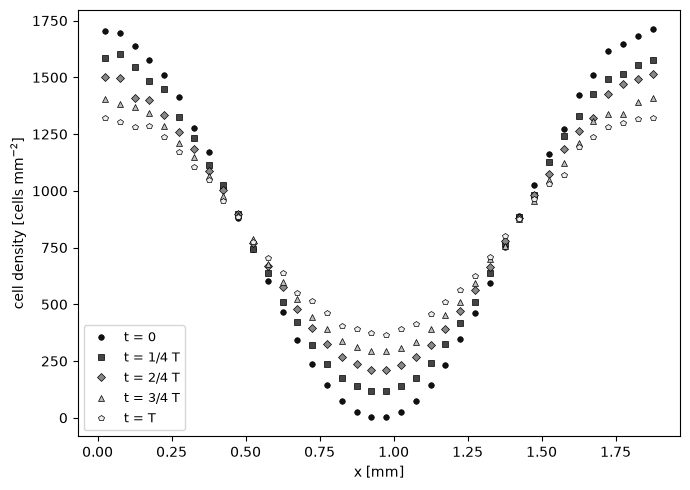

In [2]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1

CASE1_DATA_CONFIG = {
    "dataX1num": len(x),
    "dataX2num": 1,
    "dataTnum": len(t),
    "dataK": K,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "zero",
    "dataGamma": 1,
    "dataNoisePercent": 1,
    "dataNoiseSeed": 0,
}

xNum = CASE1_DATA_CONFIG["dataX1num"]
tNum = CASE1_DATA_CONFIG["dataTnum"]
gamma = CASE1_DATA_CONFIG["dataGamma"]
noise_percent = CASE1_DATA_CONFIG["dataNoisePercent"]
IC_label = CASE1_DATA_CONFIG["dataICLabel"]
seed = CASE1_DATA_CONFIG["dataNoiseSeed"]
diff_label = CASE1_DATA_CONFIG["dataDiffLabel"]
grow_label = CASE1_DATA_CONFIG["dataGrowLabel"]
dataX2num = CASE1_DATA_CONFIG["dataX2num"]

data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")
data_obj, case1_data_catalog = load_data_object(CASE1_DATA_CONFIG, DATA_ROOT, data_df=data_df)
plot_initial_condition_1d(data_obj)


## 2. Build the S2 model catalogue & form helper functions for model loading and plotting

### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed S2 data-loss comparison assumptions, and display the subset that should support the comparison panels below.

The varying dimensions in this notebook are `BNdataLossFuncLabel`, `binnES`, and `binnTVsplitSeed`; everything else is held fixed for the S2 comparison.


In [3]:
binn_df = build_model_catalog(BINN_ROOT)

binn_df


,full_path,dataX1num,dataX2num,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,...,binnRelSaveThresh,binnES,binnModelLabel,path_dict,surface_weight,pde_weight,binnActivation,perfectPDE,binnSurfaceHiddenLayers,binnDGHiddenLayers
0,/Users/willa954/Desktop/Git-personal/Hyperpara...,11,11,9,1,cos,const,linear,1,5,...,0.05,500,0,"{'dataX1num': '11', 'dataX2num': '11', 'dataTn...",NaN,NaN,NaN,NaN,NaN,NaN
1,/Users/willa954/Desktop/Git-personal/Hyperpara...,11,11,9,1,cos,const,linear,1,5,...,0.05,2000,0,"{'dataX1num': '11', 'dataX2num': '11', 'dataTn...",NaN,NaN,NaN,NaN,NaN,NaN
2,/Users/willa954/Desktop/Git-personal/Hyperpara...,11,11,9,1,cos,const,linear,1,5,...,0.05,3000,0,"{'dataX1num': '11', 'dataX2num': '11', 'dataTn...",NaN,NaN,NaN,NaN,NaN,NaN
3,/Users/willa954/Desktop/Git-personal/Hyperpara...,11,11,9,1,cos,const,linear,1,5,...,0.05,1000,0,"{'dataX1num': '11', 'dataX2num': '11', 'dataTn...",NaN,NaN,NaN,NaN,NaN,NaN
4,/Users/willa954/Desktop/Git-personal/Hyperpara...,11,11,9,1,cos,const,linear,1,5,...,0.05,500,0,"{'dataX1num': '11', 'dataX2num': '11', 'dataTn...",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,quadratic,0,0,...,0.05,3000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
473,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,quadratic,0,0,...,0.05,2000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
474,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,quadratic,0,0,...,0.05,3000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
475,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,quadratic,0,0,...,0.05,5000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, False, False)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
    "G_bound_weight": 1e4,
    "G_mono_weight": 1e4,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}
S2_NUM_PDE_SAMPLES = 100
BNDATA_LOSS_FUNC_LABELS = ["MSE", "GLS"]
FIXED_G_WIDTH = None

binn_ES_list = [500, 2000]
binnSplitSeeds = [0, 1, 2]
u_NN_lst = [64]
D_NN_lst = [4]
varyD_ES = binn_ES_list[1]
D_NN_chosen = D_NN_lst[0]

DATA_LOSS_FIXED_FILTERS = CASE1_DATA_CONFIG | {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "binnGsize": FIXED_G_WIDTH,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    "BCbool": BCbool,
    "numPDEsamples": S2_NUM_PDE_SAMPLES,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
} | active_constraint_settings(CONSTRAINT_TUPLE, CONSTRAINT_WEIGHTS, CONSTRAINT_BOUNDS)

binn_df1 = filter_model_catalog(
    binn_df,
    DATA_LOSS_FIXED_FILTERS,
    empty_message="No BINN models matched the fixed S2 data-loss comparison filters.",
)

binn_df1["BNdataLossFuncLabel"].value_counts()


BNdataLossFuncLabel
GLS    6
MSE    6
Name: count, dtype: int64

### 2.2. Helper functions for loading trained models


In [5]:
def build_data_loss_model_path(D_NN, u_NN, binnSplitSeed, binn_ES, bn_data_loss_label):
    return build_model_path(
        BINN_ROOT,
        DATA_LOSS_FIXED_FILTERS | {"BNdataLossFuncLabel": bn_data_loss_label},
        {
            "binnTVsplitSeed": binnSplitSeed,
            "binnUsize": u_NN,
            "binnDsize": D_NN,
            "binnES": binn_ES,
        },
        model_df=binn_df1,
        model_label=binn_model_num,
    )


def build_requested_data_loss_models(es_values, d_sizes, u_sizes, split_seeds, data_loss_labels):
    requested_models = []
    for bn_data_loss_label in data_loss_labels:
        for binn_ES in es_values:
            for D_NN in d_sizes:
                for u_NN in u_sizes:
                    for binnSplitSeed in split_seeds:
                        requested_models.append(
                            {
                                "BNdataLossFuncLabel": bn_data_loss_label,
                                "binnES": binn_ES,
                                "binnDsize": D_NN,
                                "binnUsize": u_NN,
                                "binnTVsplitSeed": binnSplitSeed,
                                "path": build_data_loss_model_path(
                                    D_NN,
                                    u_NN,
                                    binnSplitSeed,
                                    binn_ES,
                                    bn_data_loss_label,
                                ),
                            }
                        )
    return requested_models


def summarize_data_loss_model_availability(es_values, d_sizes, u_sizes, split_seeds, data_loss_labels):
    return summarize_requested_models(
        build_requested_data_loss_models(es_values, d_sizes, u_sizes, split_seeds, data_loss_labels),
        label_keys=["BNdataLossFuncLabel", "binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"],
    )


def load_case1_data_loss_models(es_values, d_sizes, u_sizes, split_seeds, data_loss_labels):
    requested_models = build_requested_data_loss_models(es_values, d_sizes, u_sizes, split_seeds, data_loss_labels)
    models_by_loss = {}
    for bn_data_loss_label in data_loss_labels:
        subset = [model for model in requested_models if model["BNdataLossFuncLabel"] == bn_data_loss_label]
        models_by_loss[bn_data_loss_label] = load_requested_models(
            subset,
            device=binnDevice,
            group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
        )
    return models_by_loss


model_summary = summarize_data_loss_model_availability(
    es_values=binn_ES_list,
    d_sizes=D_NN_lst,
    u_sizes=u_NN_lst,
    split_seeds=binnSplitSeeds,
    data_loss_labels=BNDATA_LOSS_FUNC_LABELS,
)

binn_models_by_loss = load_case1_data_loss_models(
    es_values=binn_ES_list,
    d_sizes=D_NN_lst,
    u_sizes=u_NN_lst,
    split_seeds=binnSplitSeeds,
    data_loss_labels=BNDATA_LOSS_FUNC_LABELS,
)


Requested model combinations: 12
Already trained model files found: 12
Missing model files: 0


### 2.3 Shared plotting style

These settings are reused across the S2 data-loss comparison panels.


In [6]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
early_stopping_markers = ["o", "s", "D", "^", "v", "P", "*", "X"]
LEGEND_SIZE_SMALL = 14
LEGEND_SIZE = 18
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}
figsize = (7, 5)
minEpoch = 0
maxEpoch = 9e3
breakEpoch = 2e2
epochAxis = {"min": minEpoch, "max": maxEpoch, "break": breakEpoch}


def plot_params_from_models(models_dict, colors):
    labels = [str(key) for key in models_dict.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dict.keys())
    }


def ground_truth_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


rawMSEs = [0.25, 0.5, 1]
mses = [scale_function_by_percent_error(ground_truth_diffusion, beta=mse)[1] for mse in rawMSEs]

name_intro_figS7 = JN_ROOT / "pngs" / "1D" / "case1" / "figS7"
os.makedirs(name_intro_figS7, exist_ok=True)


In [7]:
def build_data_loss_plot_views():
    loss_models_chosen_D = {
        label: binn_models_by_loss[label][varyD_ES][D_NN_chosen][u_NN_lst[0]]
        for label in BNDATA_LOSS_FUNC_LABELS
        if label in binn_models_by_loss
        and varyD_ES in binn_models_by_loss[label]
        and D_NN_chosen in binn_models_by_loss[label][varyD_ES]
        and u_NN_lst[0] in binn_models_by_loss[label][varyD_ES][D_NN_chosen]
    }

    loss_models_by_es = {
        ES: {
            label: binn_models_by_loss[label][ES][D_NN_chosen][u_NN_lst[0]]
            for label in BNDATA_LOSS_FUNC_LABELS
            if label in binn_models_by_loss
            and ES in binn_models_by_loss[label]
            and D_NN_chosen in binn_models_by_loss[label][ES]
            and u_NN_lst[0] in binn_models_by_loss[label][ES][D_NN_chosen]
        }
        for ES in binn_ES_list
    }
    loss_models_by_es = {ES: models_by_loss for ES, models_by_loss in loss_models_by_es.items() if models_by_loss}
    loss_models_by_es_lst = [loss_models_by_es[ES] for ES in binn_ES_list if ES in loss_models_by_es]

    early_stopping_marker_entries = [
        (str(ES), early_stopping_markers[i % len(early_stopping_markers)])
        for i, ES in enumerate(binn_ES_list)
        if ES in loss_models_by_es
    ]
    es_style_indices = [
        es_idx
        for es_idx, models_by_loss in enumerate(loss_models_by_es_lst)
        for _ in models_by_loss
    ]
    data_loss_color_indices = [
        data_loss_idx
        for models_by_loss in loss_models_by_es_lst
        for data_loss_idx, _ in enumerate(models_by_loss)
    ]

    plot_params_val = plot_params_from_models(loss_models_chosen_D, BLUE_COLORS)
    plot_params_diff = plot_params_from_models(loss_models_chosen_D, D_COLORS)

    return {
        "loss_models_chosen_D": loss_models_chosen_D,
        "loss_models_by_es_lst": loss_models_by_es_lst,
        "early_stopping_marker_entries": early_stopping_marker_entries,
        "es_style_indices": es_style_indices,
        "data_loss_color_indices": data_loss_color_indices,
        "plot_params_val": plot_params_val,
        "plot_params_diff": plot_params_diff,
    }


data_loss_plot_settings = {
    "val_legend": {
        "panel": 2,
        "loc": (1.02, 1.025),
        "loc_upd": (0.28, 1.025),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "Data loss",
         
    },
    "diff_legend": {
        "panel": 2,
        "loc": (0.635, 1),
        "loc_upd": (0.25, 1),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "Data loss",
    },
    "components_legend": {
        "panel": 2,
        "loc": (1, 1.02),
        "loc_upd": (1, 0.75),
        "fontsize": 15,
        "title_fontsize": 15,
        "ncols": 2,
        "title": "Component | data loss",
    },
    "diagnostics": [
        {
            "components": ["gls_pred_to_mse"],
            "legend": {"loc": (0.675, 0.775), "loc_upd": (0, 0.675)},
        },
        {
            "components": ["weight_pred_neff_frac"],
            "legend": {"loc": (0.6, 0.65), "loc_upd": (0.6, 0.3)},
        },
        {
            "components": ["actual_data_loss_top1_frac"],
            "legend": {"loc": (0, 0.675), "loc_upd": (0, 0.35)},
        },
    ],
    "diffusion_across_epochs_MSE": {
        "fill": True,
        "line_width": 2,
        "legends": [
            {
                "loc": (0.3, 0.3),
                "fontsize": LEGEND_SIZE,
                "ncols": 1,
                "framealpha": 0.9,
            },
            {
                "loc": (0.01, 0.4),
                "fontsize": 15,
                "ncols": 1,
                "framealpha": 0.6,
            },
        ],
        "xaxis": epochAxis,
        "fontsizes": AXIS_FONTSIZES,
        "figsize": figsize,
        "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
        "mpe": 5,
        "epoch_step": 10,
        "epoch_sf": 10,
        "D_true_label": r"$D_1$",
    },
    "diffusion_across_epochs_GLS": {
        "fill": True,
        "line_width": 2,
        "legends": [
            {
                "loc": (0.3, 0.3),
                "fontsize": LEGEND_SIZE,
                "ncols": 1,
                "framealpha": 0.9,
            },
            {
                "loc": (0.5, 0.01),
                "fontsize": 15,
                "ncols": 1,
                "framealpha": 0.6,
            },
        ],
        "xaxis": epochAxis,
        "fontsizes": AXIS_FONTSIZES,
        "figsize": figsize,
        "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
        "mpe": 5,
        "epoch_step": 10,
        "epoch_sf": 10,
        "D_true_label": r"$D_1$",
    },
}


## 3. S2 comparison plots

Generate the supplementary panels comparing the MSE and GLS data-loss formulations across validation loss, diffusion MSE, loss components, diagnostics, and diffusion evolution over training epochs.


SORTED ['GLS', 'MSE']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/plot_a


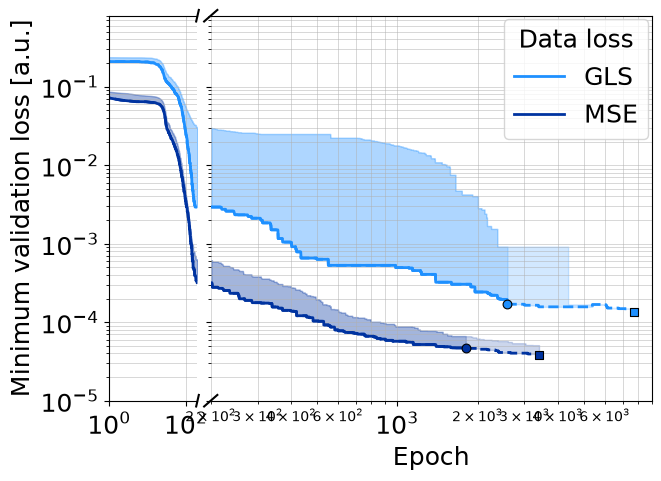

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/plot_c


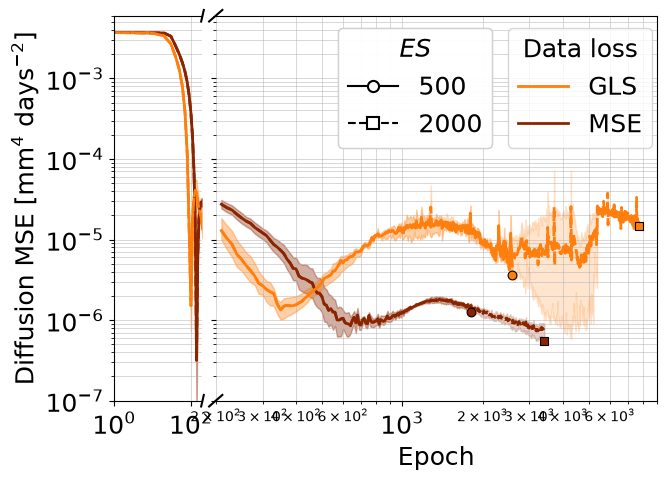

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_components.py:673: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=xaxis["min"], right=xaxis["break"])
/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_components.py:1059: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/plot_b


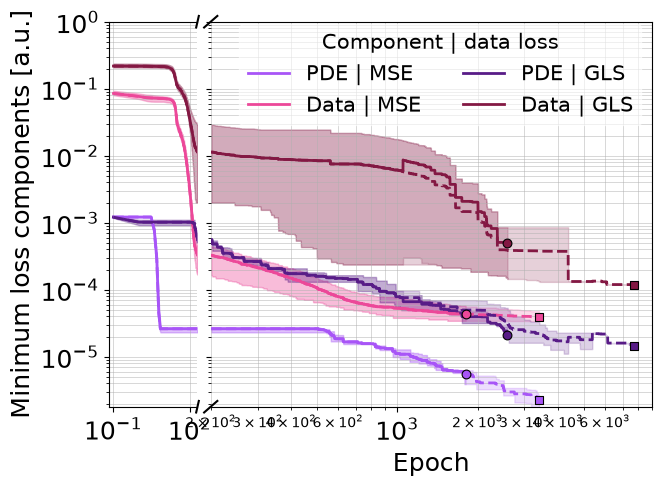

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_data_loss_diagnostics.py:416: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=xaxis["min"], right=xaxis["break"])
/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_data_loss_diagnostics.py:751: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


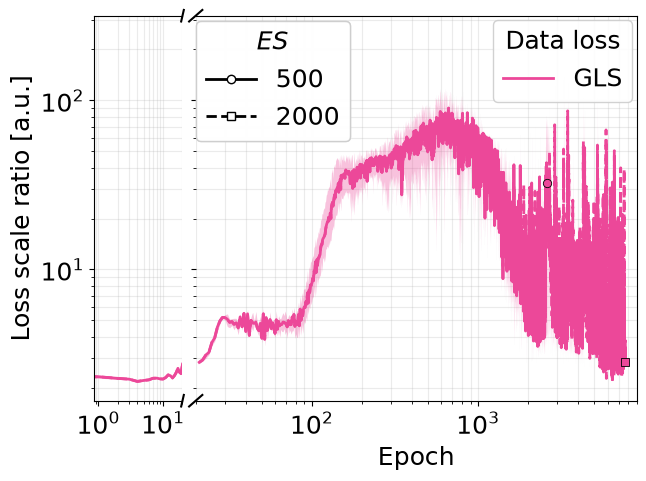

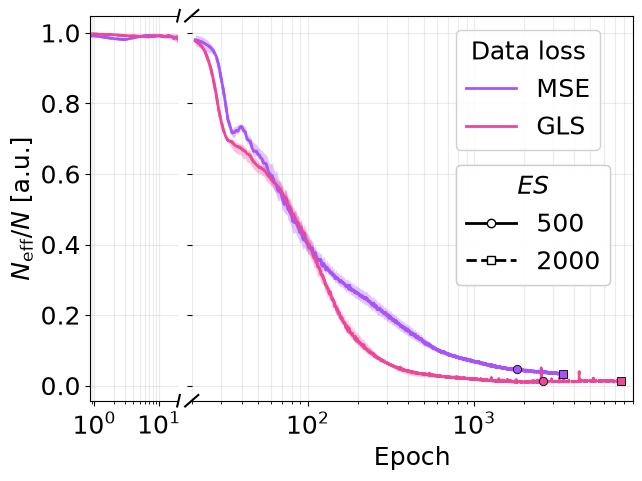

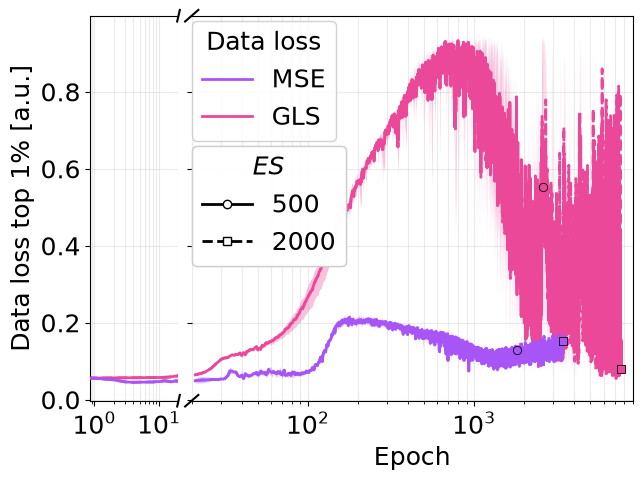

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_MSE_diffusion_MSE_model0_ylim_0p015_0p11.png


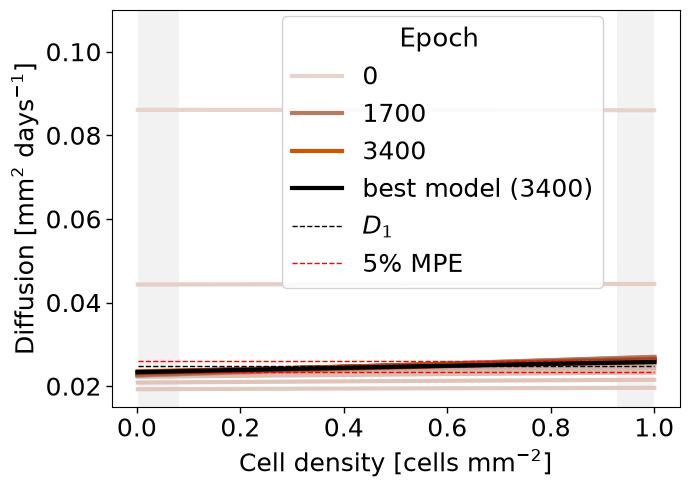

Saved diffusion plot for MSE, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_MSE_diffusion_MSE_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_MSE_diffusion_MSE_model0_ylim_0p0234_0p026.png


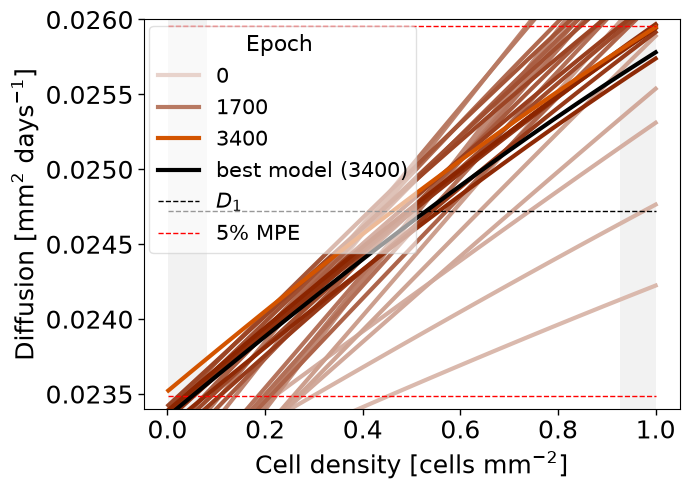

Saved diffusion plot for MSE, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_MSE_diffusion_MSE_model0_ylim_0p0234_0p026.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_GLS_diffusion_GLS_model0_ylim_0p015_0p11.png


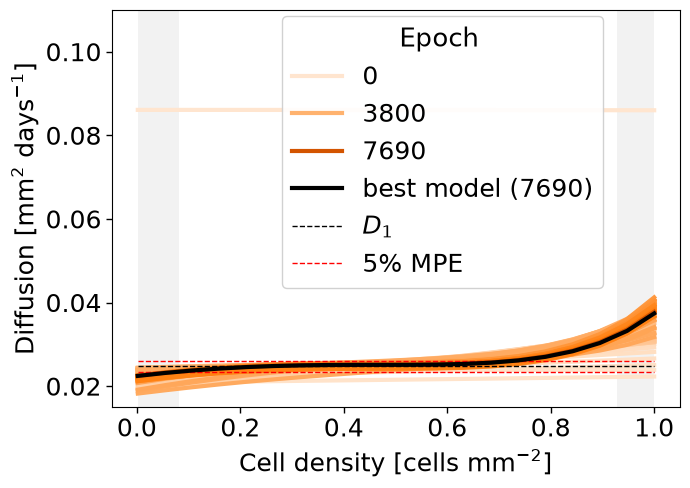

Saved diffusion plot for GLS, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_GLS_diffusion_GLS_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_GLS_diffusion_GLS_model0_ylim_0p0234_0p026.png


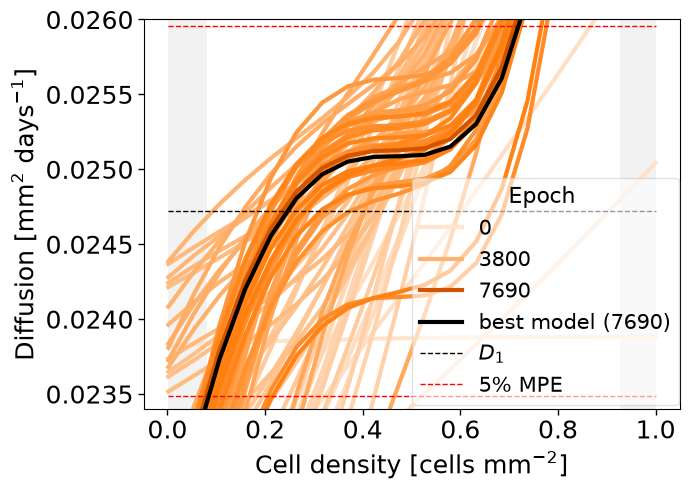

Saved diffusion plot for GLS, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS7/bottom_row_GLS_diffusion_GLS_model0_ylim_0p0234_0p026.png


In [8]:
def run_data_loss_comparison_plots(views, settings, plots_to_run=None):
    plots_to_run = {
        "min_val": True,
        "diff_MSE": True,
        "loss_components": True,
        "diagnostics": True,
        "diffusion_across_epochs": True,
        **(plots_to_run or {}),
    }

    loss_models_by_es_lst = views["loss_models_by_es_lst"]
    early_stopping_marker_entries = views["early_stopping_marker_entries"]
    es_style_indices = views["es_style_indices"]
    data_loss_color_indices = views["data_loss_color_indices"]

    if plots_to_run["min_val"]:
        plot_running_min_loss_component_broken_x_log_lst(
            models_dics_list=loss_models_by_es_lst,
            plot_params=views["plot_params_val"],
            plot_settings={
                "name": str(name_intro_figS7 / "plot_a"),
                "fill": True,
                "line_width": 2,
                "legend": settings["val_legend"],
                "xaxis": epochAxis,
                "fontsizes": AXIS_FONTSIZES,
                "figsize": figsize,
                "es_entries": early_stopping_marker_entries,
                "y_lim": (1e-5, 0.8),
                "ylabel": "Minimum validation loss [a.u.]",
            },
            loss_attr="val_loss_list",
        )

    if plots_to_run["diff_MSE"]:
        plot_running_min_MSE_diff_loss_broken_x_log_lst(
            models_dics_list=loss_models_by_es_lst,
            plot_params=views["plot_params_diff"],
            plot_settings={
                "name": str(name_intro_figS7 / "plot_c"),
                "fill": True,
                "line_width": 2,
                "legend": settings["diff_legend"],
                "xaxis": epochAxis,
                "fontsizes": AXIS_FONTSIZES,
                "figsize": figsize,
                "ylim": (1e-7, 0.6e-2),
                "es_entries": early_stopping_marker_entries,
            },
        )

    if plots_to_run["loss_components"]:
        plot_running_min_loss_components_broken_x_log_lst(
            models_dics_list=loss_models_by_es_lst,
            plot_settings={
                "name": str(name_intro_figS7 / "plot_b"),
                "fill": True,
                "ylabel": "Minimum loss components [a.u.]",
                "line_width": 2,
                "legend": settings["components_legend"],
                "xaxis": epochAxis,
                "fontsizes": AXIS_FONTSIZES,
                "figsize": figsize,
                "y_lim": (1.8e-6, 1),
                "es_entries": early_stopping_marker_entries,
                "color_indices": data_loss_color_indices,
                "marker_indices": es_style_indices,
                "line_style_indices": es_style_indices,

            },
            components={
                "pde": {"palette": ("#A855F7", "#581C87")},
                "data": {"palette": ("#EC4899", "#831843")},
            },
        )

    if plots_to_run["diagnostics"]:
        for diagnostic_settings in settings["diagnostics"]:
            legend_settings = {
                "title": "Data loss",
                "marker_title": "$ES$",
                "fontsize": LEGEND_SIZE,
                "title_fontsize": LEGEND_SIZE,
                "framealpha": 0.9,
                **diagnostic_settings["legend"],
            }
            plot_data_loss_diagnostics(
                models_dics_list=loss_models_by_es_lst,
                plot_settings={
                    "name": str(name_intro_figS7 / "row2"),
                    "split": "train",
                    "legend": legend_settings,
                    "fontsizes": AXIS_FONTSIZES,
                    "xaxis": {"min": minEpoch, "max": maxEpoch, "break": 20},
                    "components": diagnostic_settings["components"],
                    "colors": ["#A855F7", "#EC4899", "#F43F5E", "#7E22CE"],
                    "es_entries": early_stopping_marker_entries,
                    "color_indices": data_loss_color_indices,
                    "marker_indices": es_style_indices,
                    "line_style_indices": es_style_indices,
                    "figsize": figsize,
                },
           )

    if plots_to_run["diffusion_across_epochs"]:
        loss_models_chosen_D = views["loss_models_chosen_D"]
        for i, data_loss_label in enumerate(BNDATA_LOSS_FUNC_LABELS):
            if data_loss_label not in loss_models_chosen_D:
                continue

            setting = settings["diffusion_across_epochs_MSE"] if data_loss_label == "MSE" else settings["diffusion_across_epochs_GLS"]
            plot_settings = dict(setting)
            plot_settings["name"] = str(name_intro_figS7 / f"bottom_row_{data_loss_label}.png")
            plot_settings["base_color"] = D_COLORS[i]
            plot_settings["legends"] = [dict(legend) for legend in setting["legends"]]


            plot_diffusion_across_epochs(
                overwrite=True,
                models_dics_list=[loss_models_chosen_D[data_loss_label]],
                labels=[data_loss_label],
                plot_params=views["plot_params_diff"],
                plot_settings=plot_settings,
                seed_index=1,
                shade_outside_central_90=True,
            )


data_loss_views = build_data_loss_plot_views()
run_data_loss_comparison_plots(data_loss_views, data_loss_plot_settings)


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
